In [1]:
from __future__ import annotations

import sys
from dataclasses import dataclass
from pathlib import Path
from typing import Sequence

import matplotlib.pyplot as plt
import numpy as np

# Ensure local negf package is on the path
_here = Path().resolve()
_candidates = [_here, * _here.parents]
for base in _candidates:
    if (base / "negf").is_dir():
        sys.path.insert(0, str(base))
        break
    if (base / "src" / "negf").is_dir():
        sys.path.insert(0, str(base / "src"))
        break
else:
    raise ModuleNotFoundError("Cannot locate the negf package. Check the project path resolution.")

from negf.gf.recursive_greens_functions import gf_inverse
from negf import sancho_rubio_iterative_greens_function
from negf.utils.block_partition import (
    compute_block_sizes_block_tridiagonal,
    compute_block_sizes_metis,
 )



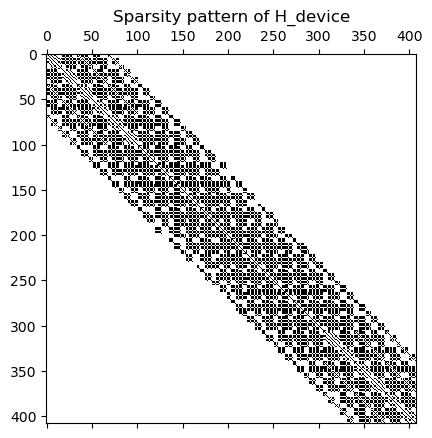

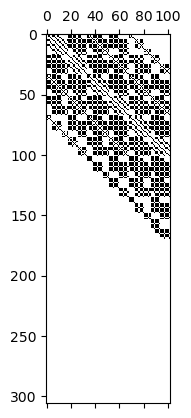

In [2]:
from pathlib import Path
import numpy as np
import scipy.linalg as la
import matplotlib.pyplot as plt

# Load QuantumATK reference data
_data_dir = Path("../DFT_data/TB_defect_graphene").resolve()
energy = np.load(_data_dir / "Energy_grid.npy")
sigma_L_ref = np.load(_data_dir / "Sigma_L_stack.npy")
sigma_R_ref = np.load(_data_dir / "Sigma_R_stack.npy")
H_left = np.load(_data_dir / "H_left.npy")
S_left = np.load(_data_dir / "S_left.npy")
H_right = np.load(_data_dir / "H_right.npy")
S_right = np.load(_data_dir / "S_right.npy")


H_device = np.load(_data_dir / "H_device.npy")
S_device = np.load(_data_dir / "S_device.npy")


plt.spy(H_device)
plt.title("Sparsity pattern of H_device")
plt.show()
n = H_left.shape[0]
plt.spy(H_device[:3*n,:n])
plt.show()

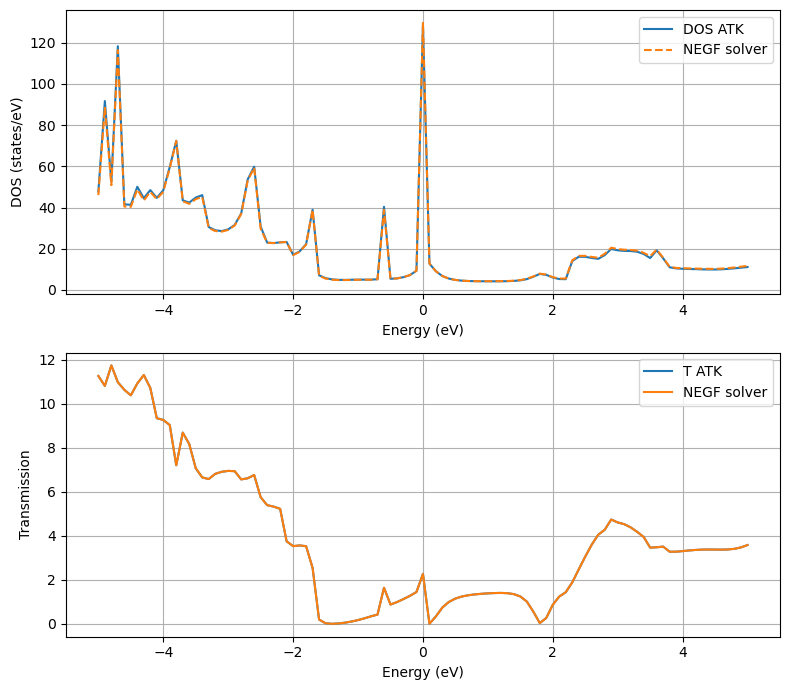

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

import multiprocessing as mp
from concurrent.futures import ProcessPoolExecutor

from negf.gf.recursive_greens_functions import _recursive_inverse
from negf import sancho_rubio_iterative_greens_function

# --- Inputs / reference data ---
_data_dir = Path("../DFT_data/TB_defect_graphene").resolve()
energy = np.load(_data_dir / "Energy_grid.npy")
H_device = np.load(_data_dir / "H_device.npy")
S_device = np.load(_data_dir / "S_device.npy")
sigma_L_ref = np.load(_data_dir / "Sigma_L_stack.npy")
sigma_R_ref = np.load(_data_dir / "Sigma_R_stack.npy")

# QuantumATK reference DOS / transmission
dos_atk = np.load(_data_dir / "DOS_total.npy")
dos_energy_atk = np.load(_data_dir / "DOS_energies_relative.npy")
T_atk = np.load(_data_dir / "Transmission_coeff.npy")
T_energy_atk = np.load(_data_dir / "Transmission_energies.npy")

# Lead blocks (used for Sancho-Rubio self-energies)
H_left_full = np.load(_data_dir / "H_left.npy")
S_left_full = np.load(_data_dir / "S_left.npy")
H_right_full = np.load(_data_dir / "H_right.npy")
S_right_full = np.load(_data_dir / "S_right.npy")

# Dimensions
n_dev = H_device.shape[0]
nL = sigma_L_ref.shape[1]  # lead principal-layer size from reference self-energies
_eta = 1e-6
_damp = 1e-6
_tol = 1e-10

# Principal-layer blocks extracted from the device (consistent with your earlier indexing)
H_left = H_device[:nL, :nL]
S_left = S_device[:nL, :nL]
H_right = H_device[-nL:, -nL:]
S_right = S_device[-nL:, -nL:]
H01_L = H_device[:nL, nL:2 * nL]
H10_L = H_device[nL:2 * nL, :nL]
S01_L = S_device[:nL, nL:2 * nL]
S10_L = S_device[nL:2 * nL, :nL]
H01_R = H_device[-nL:, -2 * nL:-nL]
H10_R = H_device[-2 * nL:-nL, -nL:]
S01_R = S_device[-nL:, -2 * nL:-nL]
S10_R = S_device[-2 * nL:-nL, -nL:]

# If you need an energy shift, do it consistently for both SR results and ATK axes.
# energy = energy - 5.0

# --- Sancho-Rubio self-energies (precompute once) ---
sigma_L_sr = np.array(
    [
        sancho_rubio_iterative_greens_function(
            float(E),
            h_l=H01_L,
            h_0=H_left,
            h_r=H10_L,
            s_l=S01_L,
            s_0=S_left,
            s_r=S10_L,
            damp=_damp,
            nconv=_tol,
        )
        for E in energy
    ]
 )

sigma_R_sr = np.array(
    [
        sancho_rubio_iterative_greens_function(
            float(E),
            h_l=H01_R,
            h_0=H_right,
            h_r=H10_R,
            s_l=S01_R,
            s_0=S_right,
            s_r=S10_R,
            damp=_damp,
            nconv=_tol,
        )
        for E in energy
    ]
 )

# --- Fixed-block recursive DOS (trace(G·S)), and full inversion for transmission ---
if n_dev % nL != 0:
    raise ValueError(
        f"Fixed-block recursive inversion requires H_device dim divisible by block size. "
        f"Got n_dev={n_dev}, block={nL}."
    )

def _embed_sigma(n: int, sigL: np.ndarray, sigR: np.ndarray) -> tuple[np.ndarray, np.ndarray]:
    """Embed lead self-energies into full device matrix corners."""
    sigL = np.asarray(sigL, dtype=complex)
    sigR = np.asarray(sigR, dtype=complex)
    mL = sigL.shape[0]
    mR = sigR.shape[0]
    Sigma_L_full = np.zeros((n, n), dtype=complex)
    Sigma_R_full = np.zeros((n, n), dtype=complex)
    Sigma_L_full[:mL, :mL] = sigL
    Sigma_R_full[-mR:, -mR:] = sigR
    return Sigma_L_full, Sigma_R_full

def _dos_and_T_one(i: int):
    E = float(energy[i])
    sigL = sigma_L_sr[i]
    sigR = sigma_R_sr[i]

    # DOS via standard recursive inversion: trace(G^R S)
    _ = _recursive_inverse(
        E,
        H_device,
        sigL,
        sigR,
        compute_lesser=False,
        overlap_matrix=S_device,
        eta=_eta,
        return_trace=True,
        return_diag=False,
        return_gamma=False,
    )
    trace_gs = _[-1]  # last return is trace when return_trace=True
    rho = -np.imag(trace_gs) / np.pi

    # Transmission via full inversion in notebook
    n = H_device.shape[0]
    Sigma_L_full, Sigma_R_full = _embed_sigma(n, sigL, sigR)
    z = E + 1j * abs(float(_eta))
    A = z * S_device - (H_device + Sigma_L_full + Sigma_R_full)
    G = np.linalg.solve(A, np.eye(n, dtype=complex))
    Gamma_L = 1j * (Sigma_L_full - Sigma_L_full.conj().T)
    Gamma_R = 1j * (Sigma_R_full - Sigma_R_full.conj().T)
    T = float(np.real(np.trace(Gamma_L @ G @ Gamma_R @ G.conj().T)))
    return rho, T

_nproc = min(16, mp.cpu_count())
_chunksize = max(1, len(energy) // (_nproc * 8))
_ctx = mp.get_context("fork")

with ProcessPoolExecutor(max_workers=_nproc, mp_context=_ctx) as ex:
    out = list(ex.map(_dos_and_T_one, range(len(energy)), chunksize=_chunksize))

rho_sr = np.array([x[0] for x in out], dtype=float)
T_sr = np.array([x[1] for x in out], dtype=float)

# --- Normalization (constant-factor fit) ---
def _fit_scale(x_ref: np.ndarray, y_ref: np.ndarray, x_model: np.ndarray, y_model: np.ndarray) -> float:
    x_ref = np.asarray(x_ref, dtype=float)
    y_ref = np.asarray(y_ref, dtype=float)
    x_model = np.asarray(x_model, dtype=float)
    y_model = np.asarray(y_model, dtype=float)
    # Interpolate reference onto model x-grid, then least-squares scale
    y_ref_on_model = np.interp(x_model, x_ref, y_ref)
    denom = float(np.dot(y_model, y_model))
    if denom == 0.0:
        return 1.0
    return float(np.dot(y_ref_on_model, y_model) / denom)

dos_scale = _fit_scale(dos_energy_atk, dos_atk, energy, rho_sr)
T_scale = _fit_scale(T_energy_atk, T_atk, energy, T_sr)
rho_sr_n = dos_scale * rho_sr
T_sr_n = T_scale * T_sr
print(f"DOS scale factor: {dos_scale:.6g}")
print(f"T scale factor:   {T_scale:.6g}")

# --- Plots: DOS and Transmission vs QuantumATK ---
fig, ax = plt.subplots(2, 1, figsize=(8, 7), sharex=True)

ax[0].plot(dos_energy_atk, dos_atk, label="DOS ATK")
ax[0].plot(energy, rho_sr, "--", label="DOS (raw)")
ax[0].plot(energy, rho_sr_n, "-", label="DOS (normalized)")
ax[0].set_ylabel("DOS")
ax[0].grid(True)
ax[0].legend()

ax[1].plot(T_energy_atk, T_atk, label="T ATK")
ax[1].plot(energy, T_sr, "--", label="T (raw)")
ax[1].plot(energy, T_sr_n, "-", label="T (normalized)")
ax[1].set_xlabel("Energy (eV)")
ax[1].set_ylabel("Transmission")
ax[1].grid(True)
ax[1].legend()

fig.tight_layout()
plt.show()

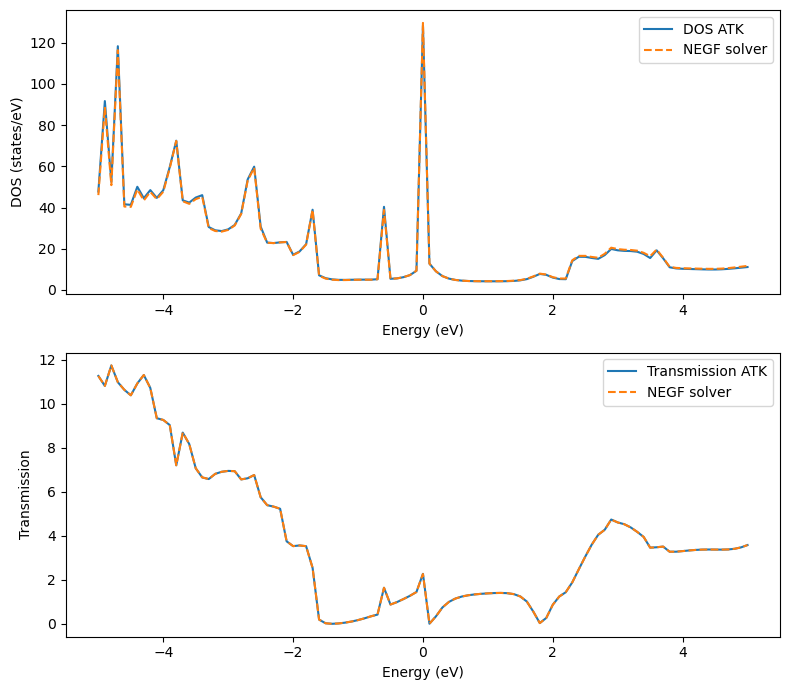

In [9]:

# --- Plots: DOS and Transmission vs QuantumATK ---
fig, ax = plt.subplots(2, 1, figsize=(8, 7), sharex=False)

ax[0].plot(dos_energy_atk, dos_atk, label="DOS ATK")
ax[0].plot(energy + 4.850288, 2*rho_sr, "--", label="NEGF solver")
ax[0].set_xlabel("Energy (eV)")
ax[0].set_ylabel("DOS (states/eV)")

ax[0].legend()

ax[1].plot(T_energy_atk, T_atk, label="Transmission ATK")
ax[1].plot(energy + 4.850288, 2*T_sr,"--", label="NEGF solver")
ax[1].set_xlabel("Energy (eV)")
ax[1].set_ylabel("Transmission")

ax[1].legend()

fig.tight_layout()
plt.show()